<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/smartflow_colab_dashboard_with_thresholds_and_exports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartFlow Reactor™ Full Kinetics Dashboard with Dynamic and Static Charts

In [1]:
import pandas as pd
import plotly.graph_objs as go
import ipywidgets as widgets
from IPython.display import display, Markdown

In [5]:
# Upload the full kinetics CSV file
def upload_csv():
    from google.colab import files
    uploaded = files.upload()
    return pd.read_csv(list(uploaded.keys())[0])

df = upload_csv()

Saving SmartFlow_Industrial_Validation_Template.csv to SmartFlow_Industrial_Validation_Template.csv


In [6]:

# Load thresholds from external CSV
threshold_df = pd.read_csv("SmartFlow_Thresholds.csv")
threshold_map = dict(zip(threshold_df["Parameter"], threshold_df["Threshold"]))

def plot_kinetics(parameter='PFAS_total_ngL', threshold=None):
    # Automatically use threshold from file if not manually provided
    if threshold is None and parameter in threshold_map:
        threshold = threshold_map[parameter]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df['Time_minutes'], y=df[parameter],
                             mode='lines', name=parameter, line=dict(color='blue')))

    if threshold is not None:
        fig.add_hline(y=threshold, line=dict(color='red', dash='dash'))
        current_val = df[parameter].iloc[-1]
        status = "⚠️ Exceeds threshold!" if current_val > threshold else "✅ Within safe range"
        display(Markdown(f"### {status} (Final value: {current_val:.2f})"))

    fig.update_layout(title=f'{parameter} Kinetics Over Time',
                      xaxis_title='Time (minutes)', yaxis_title=parameter.replace('_', ' '),
                      height=500)
    fig.show()

param_dropdown = widgets.Dropdown(
    options=[col for col in df.columns if col != 'Time_minutes'],
    value='PFAS_total_ngL' if 'PFAS_total_ngL' in df.columns else df.columns[1],
    description='Parameter:',
    style={'description_width': 'initial'}
)

threshold_input = widgets.FloatText(
    value=threshold_map.get(param_dropdown.value, 70.0),
    description='Threshold (optional):',
    style={'description_width': 'initial'}
)

widgets.interact(plot_kinetics, parameter=param_dropdown, threshold=threshold_input);


interactive(children=(Dropdown(description='Parameter:', index=1, options=('Timestamp_ISO8601', 'PFAS_total_ng…

## 📊 Static Chart Panel for All Parameters

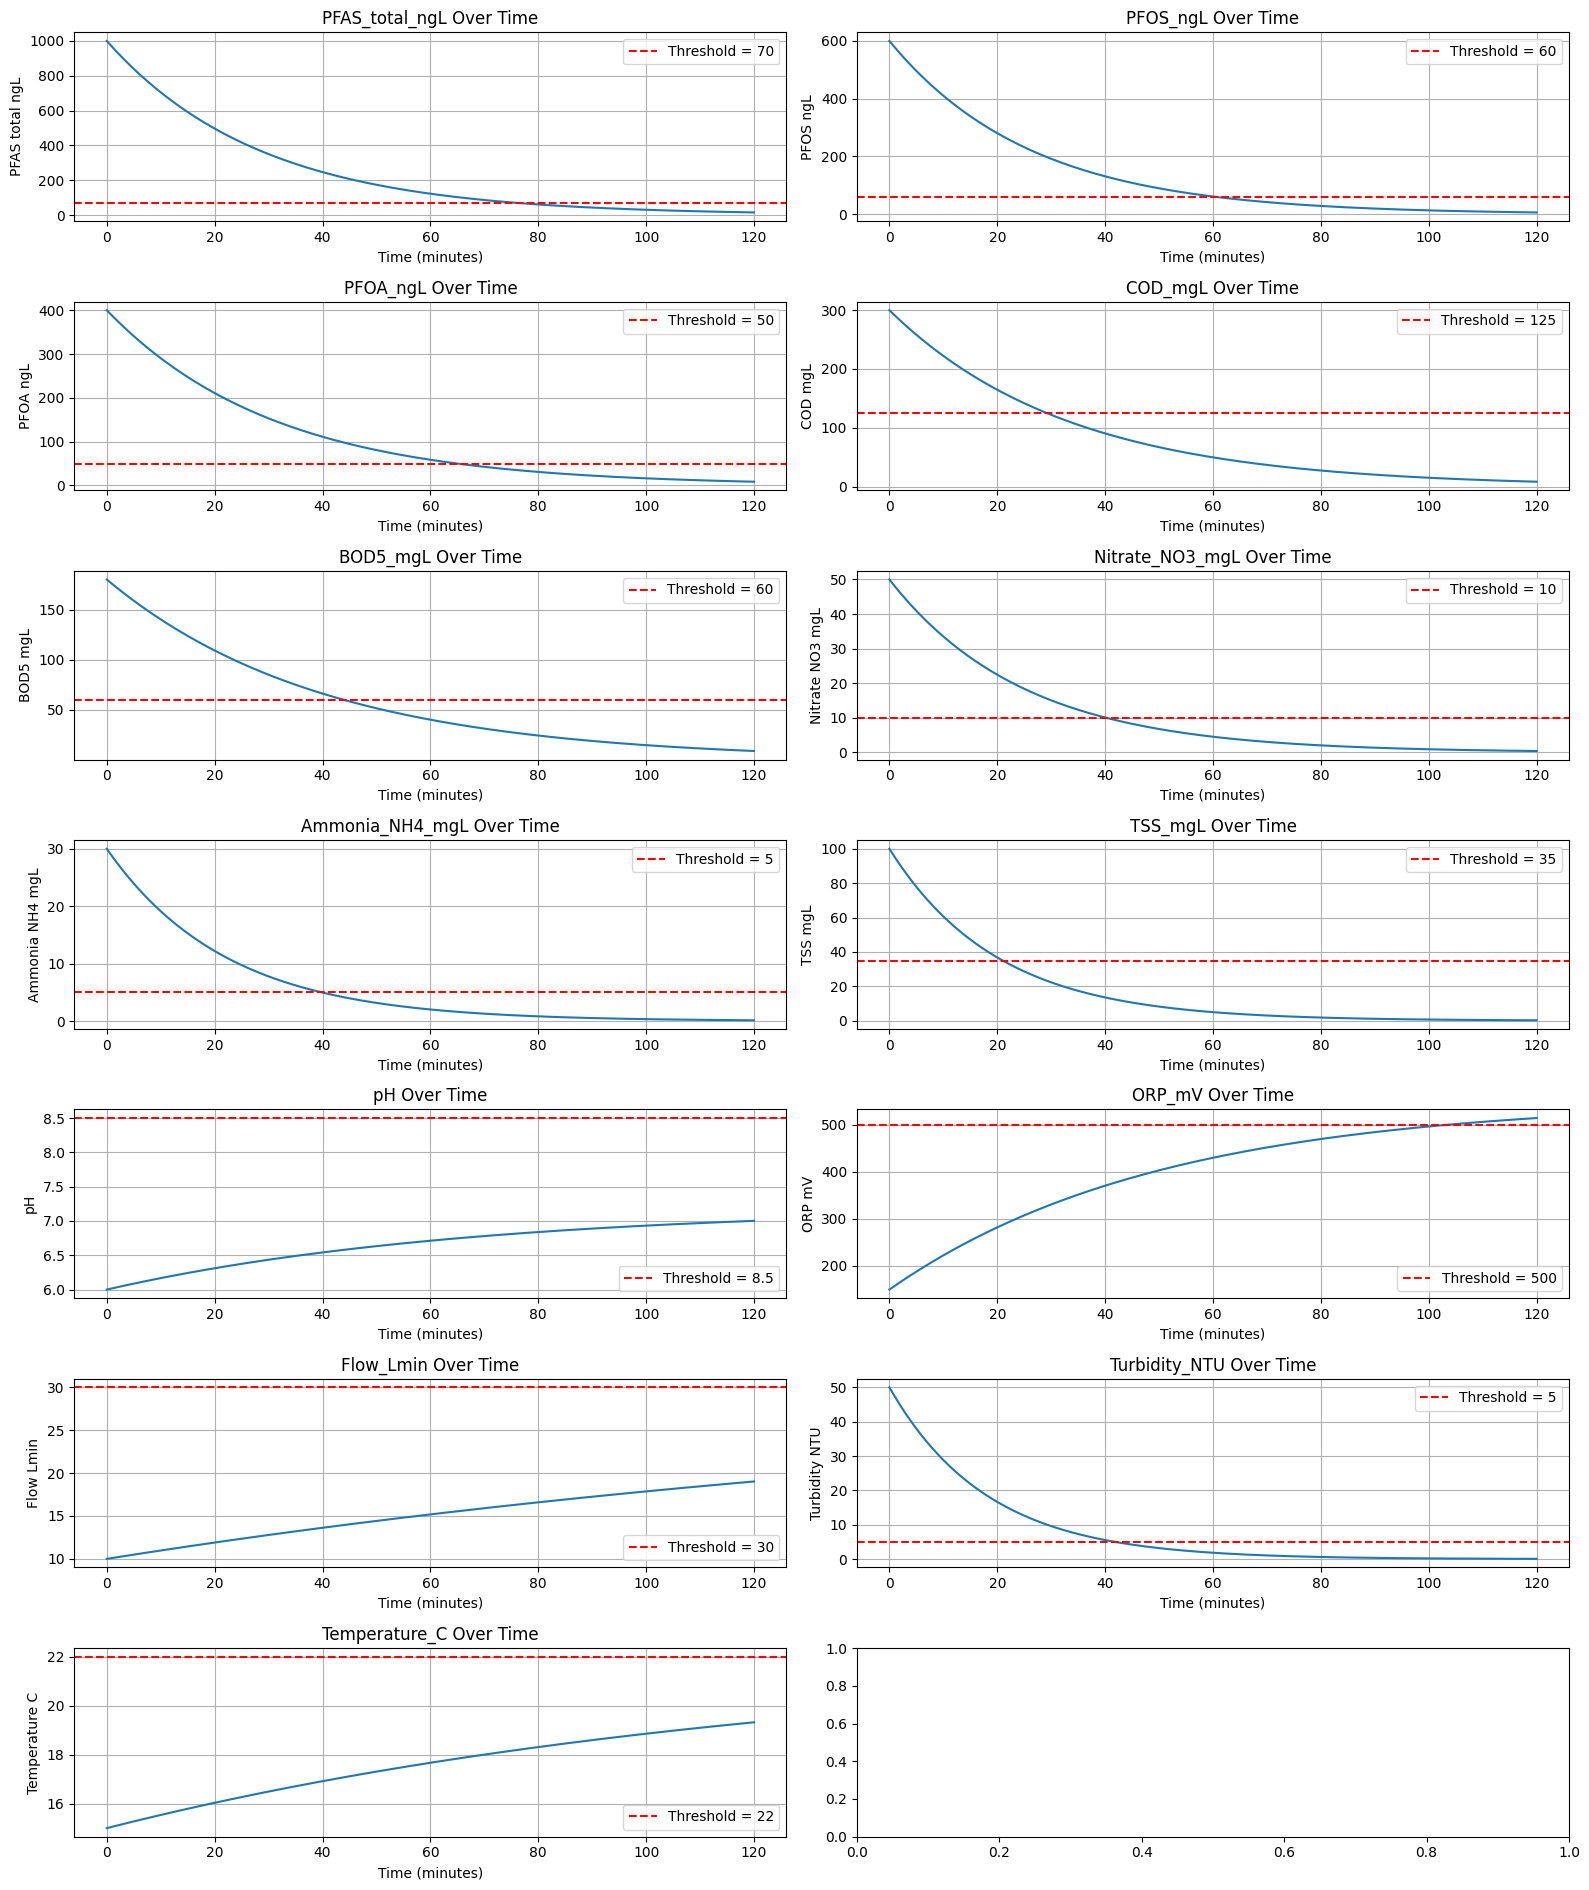

In [4]:

# 📊 Static Chart Panel for All Parameters (with threshold lines + image export)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Default thresholds
thresholds = {
    "PFAS_total_ngL": 70,
    "PFOS_ngL": 60,
    "PFOA_ngL": 50,
    "COD_mgL": 125,
    "BOD5_mgL": 60,
    "Nitrate_NO3_mgL": 10,
    "Ammonia_NH4_mgL": 5,
    "TSS_mgL": 35,
    "pH": 8.5,
    "ORP_mV": 500,
    "Flow_Lmin": 30,
    "Turbidity_NTU": 5,
    "Temperature_C": 22
}

# Ensure output folder exists
os.makedirs("smartflow_charts", exist_ok=True)

# Time and params
time = df['Time_minutes']
params = [col for col in df.columns if col != 'Time_minutes']

# Full dashboard view
fig, axes = plt.subplots(nrows=len(params)//2 + 1, ncols=2, figsize=(16, 3 * len(params)//2))
axes = axes.flatten()

for idx, param in enumerate(params):
    ax = axes[idx]
    sns.lineplot(x=time, y=df[param], ax=ax)

    if param in thresholds:
        ax.axhline(y=thresholds[param], color='red', linestyle='--', label=f'Threshold = {thresholds[param]}')
        ax.legend()

    ax.set_title(f'{param} Over Time')
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel(param.replace('_', ' '))
    ax.grid(True)

    # Save each chart as PNG + SVG
    fig_indiv, ax_indiv = plt.subplots(figsize=(8, 4))
    sns.lineplot(x=time, y=df[param], ax=ax_indiv)
    if param in thresholds:
        ax_indiv.axhline(y=thresholds[param], color='red', linestyle='--', label=f'Threshold = {thresholds[param]}')
        ax_indiv.legend()
    ax_indiv.set_title(f'{param} Over Time')
    ax_indiv.set_xlabel('Time (minutes)')
    ax_indiv.set_ylabel(param.replace('_', ' '))
    ax_indiv.grid(True)
    fig_indiv.tight_layout()
    fig_indiv.savefig(f"smartflow_charts/{param}.png", format='png')
    fig_indiv.savefig(f"smartflow_charts/{param}.svg", format='svg')
    plt.close(fig_indiv)

# Show dashboard
plt.tight_layout()
plt.show()
